# Machine Learning for EEG signals

In this notebook, we explore classical machine learning methods for classifying electroencephalography (EEG) signals of motor imagery (MI) – imagined movements of the **both hands** and **both feet**, analyzed using channels **C3**, **Cz**, and **C4**, which cover the sensorimotor cortex.

**Data:** PhysioNet EEG Motor Movement/Imagery Dataset (EEGMMIDB): https://www.physionet.org/content/eegmmidb/1.0.0/

- Run mapping:

        - 1 = baseline eyes open
        - 2 = baseline eyes closed
        - 3, 7, 11 = executed left/right hand
        - 4, 8, 12 = imagined left/right hand
        - 5, 9, 13 = executed hands/feet
        - 6, 10, 14 = imagined hands/feet

- Alternative site (same dataset): https://moabb.neurotechx.com/docs/generated/moabb.datasets.PhysionetMI.html

## 1. Exploratory Data Analysis

In [78]:
import pandas as pd
from collections import Counter
from mne.io import read_raw_edf
from mne.datasets import eegbci

N_SUBJECTS = 109
subjects = range(1, N_SUBJECTS + 1)

run_types = {
    1: "Baseline (Eyes open)",
    2: "Baseline (Eyes closed)",
    3: "Executed: Left/Right fist",
    4: "Imagined: Left/Right fist",
    5: "Executed: Both fists/Feet",
    6: "Imagined: Both fists/Feet",
    7: "Executed: Left/Right fist",
    8: "Imagined: Left/Right fist",
    9: "Executed: Both fists/Feet",
    10: "Imagined: Both fists/Feet",
    11: "Executed: Left/Right fist",
    12: "Imagined: Left/Right fist",
    13: "Executed: Both fists/Feet",
    14: "Imagined: Both fists/Feet",
}

RUNS = [6, 10, 14]  # we only focus on imagined both hands/feet

print(f"Total number of subjects: {N_SUBJECTS}")
print(f"Runs: {RUNS} (Imagined both fists vs. both feet)")

summary = []

from tqdm import tqdm

for subject in tqdm(subjects, desc="Subjects"):
    files = eegbci.load_data(subject, runs=RUNS)

    for file, run in zip(files, RUNS):
        raw = read_raw_edf(file, preload=False)

        events = Counter(raw.annotations.description)

        summary.append({
            "Subject": subject,
            "Run": run,
            "Run type": run_types[run],
            "Duration [s]": round(raw.times[-1], 1),
            "Channels": raw.info["nchan"],
            "Sampling freq.": raw.info["sfreq"],
            "T0": events.get("T0", 0),
            "T1": events.get("T1", 0),
            "T2": events.get("T2", 0),
        })

summary = pd.DataFrame(summary)



Total number of subjects: 109
Runs: [6, 10, 14] (Imagined both fists vs. both feet)


Subjects:   0%|          | 0/109 [00:00<?, ?it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R10.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R14.edf...
Setting channel info structure...
Creating raw.info structure...


Subjects:   1%|          | 1/109 [00:00<00:12,  8.68it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R06.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R10.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R14.edf...
Setting channel info structure...
Creating raw.info structure...


...

Subjects:  97%|█████████▋| 106/109 [00:10<00:00,  9.71it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S107\S107R06.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S107\S107R10.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S107\S107R14.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S108\S108R06.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S108\S108R10.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S108\

Subjects:  99%|█████████▉| 108/109 [00:11<00:00, 10.04it/s]

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S109\S109R06.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S109\S109R10.edf...
Setting channel info structure...
Creating raw.info structure...
Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S109\S109R14.edf...
Setting channel info structure...
Creating raw.info structure...


Subjects: 100%|██████████| 109/109 [00:11<00:00,  9.67it/s]


### 1.1 General summary & statistics

In [79]:
summary.info()
summary

<class 'pandas.DataFrame'>
RangeIndex: 327 entries, 0 to 326
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Subject         327 non-null    int64  
 1   Run             327 non-null    int64  
 2   Run type        327 non-null    str    
 3   Duration [s]    327 non-null    float64
 4   Channels        327 non-null    int64  
 5   Sampling freq.  327 non-null    float64
 6   T0              327 non-null    int64  
 7   T1              327 non-null    int64  
 8   T2              327 non-null    int64  
dtypes: float64(2), int64(6), str(1)
memory usage: 23.1 KB


,Subject,Run,Run type,Duration [s],Channels,Sampling freq.,T0,T1,T2
0,1,6,Imagined: Both fists/Feet,125.0,64,160.0,15,7,8
1,1,10,Imagined: Both fists/Feet,125.0,64,160.0,15,7,8
2,1,14,Imagined: Both fists/Feet,125.0,64,160.0,15,7,8
3,2,6,Imagined: Both fists/Feet,123.0,64,160.0,15,8,7
4,2,10,Imagined: Both fists/Feet,123.0,64,160.0,15,8,7
...,...,...,...,...,...,...,...,...,...
322,108,10,Imagined: Both fists/Feet,123.0,64,160.0,15,7,8
323,108,14,Imagined: Both fists/Feet,123.0,64,160.0,15,8,7
324,109,6,Imagined: Both fists/Feet,123.0,64,160.0,15,8,7
325,109,10,Imagined: Both fists/Feet,123.0,64,160.0,15,8,7


In [80]:
summary.describe(include="all")

,Subject,Run,Run type,Duration [s],Channels,Sampling freq.,T0,T1,T2
count,327.000000,327.000000,327,327.000000,327.0,327.000000,327.000000,327.000000,327.000000
unique,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Imagined: Both fists/Feet,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,327,NaN,NaN,NaN,NaN,NaN,NaN
mean,55.000000,10.000000,NaN,123.461774,64.0,159.119266,15.045872,7.538226,7.507645
std,31.512487,3.270992,NaN,0.808832,0.0,5.243269,0.612528,0.604868,0.564086
min,1.000000,6.000000,NaN,123.000000,64.0,128.000000,12.000000,6.000000,6.000000
25%,28.000000,6.000000,NaN,123.000000,64.0,160.000000,15.000000,7.000000,7.000000
50%,55.000000,10.000000,NaN,123.000000,64.0,160.000000,15.000000,8.000000,7.000000
75%,82.000000,14.000000,NaN,124.000000,64.0,160.000000,15.000000,8.000000,8.000000


### 1.2. Unique values, missing values, duplicates

In [81]:
# UNIQUE VALUES
for col in summary.columns:
    print(f"\n{col}")
    print(summary[col].unique())


Subject
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109]

Run
[ 6 10 14]

Run type
<StringArray>
['Imagined: Both fists/Feet']
Length: 1, dtype: str

Duration [s]
[125. 123. 124.]

Channels
[64]

Sampling freq.
[160. 128.]

T0
[15 19 12]

T1
[ 7  8 10  9  6]

T2
[ 8  7  9 10  6]


In [82]:
# MISSING VALUES
summary.isna().sum()

Subject           0
Run               0
Run type          0
Duration [s]      0
Channels          0
Sampling freq.    0
T0                0
T1                0
T2                0
dtype: int64

In [83]:
# DUPLICATED RECORDINGS
summary.duplicated().sum()

np.int64(0)

### 1.3. Run consistency

In [84]:
summary.groupby("Run").agg({
    "Duration [s]": ["min", "max", "mean", "std"],
    "Channels": ["min", "max"],
    "Sampling freq.": ["min", "max"],
    "T0": ["min", "max"],
    "T1": ["min", "max"],
    "T2": ["min", "max"],
})

Duration [s]                              Channels     Sampling freq.  \
             min    max        mean       std      min max            min   
Run                                                                         
6          123.0  125.0  123.458716  0.811173       64  64          128.0   
10         123.0  125.0  123.458716  0.811173       64  64          128.0   
14         123.0  125.0  123.467890  0.811592       64  64          128.0   

            T0      T1      T2      
       max min max min max min max  
Run                                 
6    160.0  12  19   6  10   6   9  
10   160.0  12  19   6  10   6   9  
14   160.0  12  19   6  10   6  10

In [85]:
summary.groupby("Run type").agg({
    "Duration [s]": ["mean", "std"],
    "T0": "mean",
    "T1": "mean",
    "T2": "mean",
})

Duration [s]                   T0        T1  \
                                  mean       std       mean      mean   
Run type                                                                
Imagined: Both fists/Feet   123.461774  0.808832  15.045872  7.538226   

                                 T2  
                               mean  
Run type                             
Imagined: Both fists/Feet  7.507645

In [86]:
summary.groupby("Run")[["T0", "T1", "T2"]].value_counts().sort_index()

Run  T0  T1  T2
6    12  6   6      1
     15  7   8     49
         8   7     57
     19  10  9      2
10   12  6   6      1
     15  7   8     54
         8   7     52
     19  10  9      2
14   12  6   6      1
     15  7   8     53
         8   7     53
     19  9   10     1
         10  9      1
Name: count, dtype: int64

## 2. Feature engineering
- epoching + feature extraction for runs 6, 10, 14, channels C3, Cz, C4, labels T1 = imagined fists, T2 = imagined feet

### 2.1 Epoching

In [87]:
import numpy as np
import pandas as pd

from tqdm import tqdm
from scipy.stats import skew, kurtosis
from scipy.signal import welch

import mne
from mne.io import read_raw_edf
from mne.datasets import eegbci

import antropy as ant
import nolds

N_SUBJECTS = 109
SUBJECTS = range(1, N_SUBJECTS + 1)
RUNS = [6, 10, 14]

CHANNELS = ["C3", "Cz", "C4"]

# Motor imagery task:
# T1 = imagined both fists
# T2 = imagined both feet
EVENT_ID = {
    "T1": 2,
    "T2": 3,
}

LABEL_NAMES = {
    "T1": "Imagined fists",
    "T2": "Imagined feet",
}

TMIN = 0.0
TMAX = 4.0

FMIN = 1.0
FMAX = 40.0

epoch_rows = []

for subject in tqdm(SUBJECTS, desc="Epoching subjects"):

    files = eegbci.load_data(subject, runs=RUNS)

    for file, run in zip(files, RUNS):

        raw = read_raw_edf(file, preload=True, verbose=False)

        eegbci.standardize(raw)

        raw.pick(CHANNELS)

        raw.filter(
            l_freq=FMIN,
            h_freq=FMAX,
            fir_design="firwin",
            verbose=False
        )

        events, _ = mne.events_from_annotations(raw, verbose=False)

        epochs = mne.Epochs(
            raw,
            events,
            event_id=EVENT_ID,
            tmin=TMIN,
            tmax=TMAX,
            baseline=None,
            preload=True,
            verbose=False
        )

        sfreq = epochs.info["sfreq"]
        data = epochs.get_data(copy=True) * 1e6  # V -> µV

        inv_event_id = {v: k for k, v in EVENT_ID.items()}

        for epoch_idx, epoch_data in enumerate(data):

            label_code = epochs.events[epoch_idx, -1]
            label = inv_event_id[label_code]

            row = {
                "subject": subject,
                "run": run,
                "epoch": epoch_idx,
                "label": label,
                "label_name": LABEL_NAMES[label],
                "sfreq": sfreq,
            }

            for ch_idx, channel in enumerate(CHANNELS):
                row[channel] = epoch_data[ch_idx]

            epoch_rows.append(row)

epochs_df = pd.DataFrame(epoch_rows)

print(epochs_df.shape)
print(epochs_df["label"].value_counts())

epochs_df.head()

Epoching subjects:  91%|█████████ | 99/109 [00:12<00:01,  7.75it/s]C:\Users\Nikolina\AppData\Local\Temp\ipykernel_1428\724288072.py:48: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = read_raw_edf(file, preload=True, verbose=False)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_1428\724288072.py:48: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = read_raw_edf(file, preload=True, verbose=False)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_1428\724288072.py:48: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = read_raw_edf(file, preload=True, verbose=False)
Epoching subjects: 100%|██████████| 109/109 [00:13<00:00,  7.80it/s]

(4897, 9)
label
T1    2452
T2    2445
Name: count, dtype: int64


,subject,run,epoch,label,label_name,sfreq,C3,Cz,C4
0,1,6,0,T2,Imagined feet,160.0,"[47.064663920283344, 51.896709824210674, 64.30...","[61.599042378512515, 60.9579394782651, 68.9704...","[46.20212460673687, 53.750296419015655, 60.365..."
1,1,6,1,T1,Imagined fists,160.0,"[34.8853482605296, 26.828342214257756, 7.53468...","[38.7231736898472, 32.90767454071031, 11.45478...","[43.6375697126612, 34.166421250550584, 17.8051..."
2,1,6,2,T1,Imagined fists,160.0,"[-21.571030741303048, -32.208187289640755, -43...","[-35.163623742622505, -48.6533153732969, -50.7...","[5.6637498680118785, -12.753106114879428, -31...."
3,1,6,3,T2,Imagined feet,160.0,"[60.67600003103479, 54.99254902629978, 40.7286...","[55.49427777438765, 40.40204857717364, 28.6282...","[44.692733335014445, 23.807781532792806, 14.79..."
4,1,6,4,T1,Imagined fists,160.0,"[105.52078890294472, 113.71931957723163, 122.0...","[126.98589352009795, 141.76272358736384, 154.2...","[89.84783019086548, 99.53227522632251, 104.020..."


### 2.2 Feature extraction

For each epoch and each motor cortex channel (**C3**, **Cz**, and **C4**), we compute a set of features describing the EEG signal from multiple perspectives.

| Feature category | Features |
|------------------|----------|
| **Time-domain** | Mean, Variance, Standard deviation, Root mean square (RMS), Peak-to-peak amplitude, Skewness, Kurtosis |
| **Frequency-domain** | Delta (1–4 Hz), Theta (4–8 Hz), Alpha (8–13 Hz), and Beta (13–30 Hz) absolute band powers, Relative delta/theta/alpha/beta band powers, Dominant frequency |
| **Nonlinear** | Sample entropy, Higuchi fractal dimension, Correlation dimension, Largest Lyapunov exponent |

For nonlinear features based on phase-space reconstruction (correlation dimension and largest Lyapunov exponent), we reuse the embedding parameters determined in the previous notebook (*Nonlinear analysis*).

The resulting feature vector contains a total of **60 EEG features** per epoch:

- **7 time-domain features × 3 channels = 21 features**
- **9 frequency-domain features × 3 channels = 27 features**
- **4 nonlinear features × 3 channels = 12 features**


In [62]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

import antropy as ant
import nolds

m_mi = 5

embedding_params_mi = {
    "long_tau": {
        "C3": {"tau": 28, "m": m_mi},
        "Cz": {"tau": 27, "m": m_mi},
        "C4": {"tau": 29, "m": m_mi},
    },
    "short_tau": {
        "C3": {"tau": 10, "m": m_mi},
        "Cz": {"tau": 27, "m": m_mi},
        "C4": {"tau": 10, "m": m_mi},
    },
}

def bandpower_welch(x, sfreq, band, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), int(2 * sfreq))

    freqs, psd = welch(x, fs=sfreq, nperseg=nperseg)

    mask = (freqs >= band[0]) & (freqs <= band[1])

    if not np.any(mask):
        return np.nan

    return np.trapezoid(psd[mask], freqs[mask])


def dominant_frequency(x, sfreq, fmin=1.0, fmax=30.0, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), int(2 * sfreq))

    freqs, psd = welch(x, fs=sfreq, nperseg=nperseg)

    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.nan

    freqs_sel = freqs[mask]
    psd_sel = psd[mask]

    return freqs_sel[np.argmax(psd_sel)]

def extract_channel_features(x, sfreq, channel):
    features = {}

    # Time-domain features
    features["mean"] = np.mean(x)
    features["variance"] = np.var(x)
    features["std"] = np.std(x)
    features["rms"] = np.sqrt(np.mean(x ** 2))
    features["ptp"] = np.ptp(x)
    features["skewness"] = skew(x)
    features["kurtosis"] = kurtosis(x)

    # Frequency-domain features
    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
    }

    abs_powers = {}

    for band_name, band_range in bands.items():
        power = bandpower_welch(x, sfreq, band_range)
        abs_powers[band_name] = power
        features[f"{band_name}_power"] = power

    total_power = bandpower_welch(x, sfreq, (1, 30))

    for band_name, power in abs_powers.items():
        features[f"relative_{band_name}_power"] = (
            power / total_power if total_power > 0 else np.nan
        )

    features["dominant_frequency"] = dominant_frequency(x, sfreq)

    # Nonlinear features
    features["sample_entropy"] = ant.sample_entropy(x)
    features["higuchi_fd"] = ant.higuchi_fd(x, kmax=8)

    for param_name, param_set in embedding_params_mi.items():
        params = param_set[channel]
        tau = params["tau"]
        m = params["m"]

        try:
            features[f"correlation_dimension_{param_name}"] = nolds.corr_dim(
                x,
                emb_dim=m,
                lag=tau
            )
        except Exception:
            features[f"correlation_dimension_{param_name}"] = np.nan

        try:
            features[f"lyapunov_exponent_{param_name}"] = nolds.lyap_r(
                x,
                emb_dim=m,
                lag=tau,
                min_tsep=10,
                trajectory_len=20,
                fit="poly"
            )
        except Exception:
            features[f"lyapunov_exponent_{param_name}"] = np.nan

    return features


feature_rows = []

for _, epoch in tqdm(epochs_df.iterrows(), total=len(epochs_df), desc="Extracting features"):

    row = {
        "subject": epoch["subject"],
        "run": epoch["run"],
        "epoch": epoch["epoch"],
        "label": epoch["label"],
        "label_name": epoch["label_name"],
    }

    for channel in CHANNELS:

        x = epoch[channel]
        sfreq = epoch["sfreq"]
        label = epoch["label"]

        feats = extract_channel_features(
            x=x,
            sfreq=sfreq,
            channel=channel
        )

        for feat_name, feat_value in feats.items():
            row[f"{channel}_{feat_name}"] = feat_value

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print(features_df.shape)
print(features_df["label"].value_counts())
features_df.to_csv("bci_mi_features_all_subjects.csv", index=False)

features_df.head()

Extracting features:   0%|          | 0/4897 [00:00<?, ?it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
Extracting features:   0%|          | 8/4897 [00:01<13:54,  5.86it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
Extracting features:   1%|          | 35/4897 [00:05<13:20,  6.07it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
Extracting features:   1%|          | 42/4897 [00:07<14:18,  5.66it/s]C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-pac

(4897, 71)
label
T1    2452
T2    2445
Name: count, dtype: int64


,subject,run,epoch,label,label_name,C3_mean,C3_variance,C3_std,C3_rms,C3_ptp,...,C4_relative_theta_power,C4_relative_alpha_power,C4_relative_beta_power,C4_dominant_frequency,C4_sample_entropy,C4_higuchi_fd,C4_correlation_dimension_long_tau,C4_lyapunov_exponent_long_tau,C4_correlation_dimension_short_tau,C4_lyapunov_exponent_short_tau
0,1,6,0,T2,Imagined feet,0.356340,1216.006590,34.871286,34.873107,226.940992,...,0.227415,0.222097,0.152297,1.5,0.961899,1.460214,0.032370,0.036353,0.002600,0.023637
1,1,6,1,T1,Imagined fists,2.143106,3153.061461,56.152128,56.193010,344.902928,...,0.094585,0.046270,0.074948,1.0,0.803102,1.507048,0.163384,0.034462,0.140468,0.021338
2,1,6,2,T1,Imagined fists,0.580675,2456.550167,49.563597,49.566999,312.839265,...,0.231137,0.114749,0.081215,1.0,0.830336,1.405802,0.234100,0.036830,0.070811,0.025787
3,1,6,3,T2,Imagined feet,-0.717332,1426.638502,37.770868,37.777679,258.215062,...,0.105793,0.191095,0.143566,2.0,1.048014,1.458510,0.052538,0.031772,0.009228,0.023967
4,1,6,4,T1,Imagined fists,3.082512,6218.548340,78.857773,78.917997,679.794566,...,0.133573,0.091695,0.079308,1.0,0.590742,1.419016,0.661582,0.035352,1.383028,0.020298


### 2.3. Feature selection
Steps:
1. simple **subject-wise stratified split**
2. **z-score** normalization - since many features are measured on different scales (fit on train)
3. **corelation analysis**
4. **feature selection** using univariate filter methods ANOVA F-test and Mutual Information


#### SUBJECT-WISE STARTIFIED SPLIT

In [63]:
from sklearn.model_selection import GroupShuffleSplit

metadata = ["subject", "run", "epoch", "label", "label_name"]

X = features_df.drop(columns=metadata)
y = features_df["label"]

groups = features_df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print("Train subjects:", features_df.iloc[train_idx]["subject"].nunique())
print("Test subjects :", features_df.iloc[test_idx]["subject"].nunique())

print(
    set(features_df.iloc[train_idx]["subject"])
    & set(features_df.iloc[test_idx]["subject"])
)

Train subjects: 87
Test subjects : 22
set()


#### Z-SCORE NORMALIZATION

In [64]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

#### CORRELATION ANALYSIS

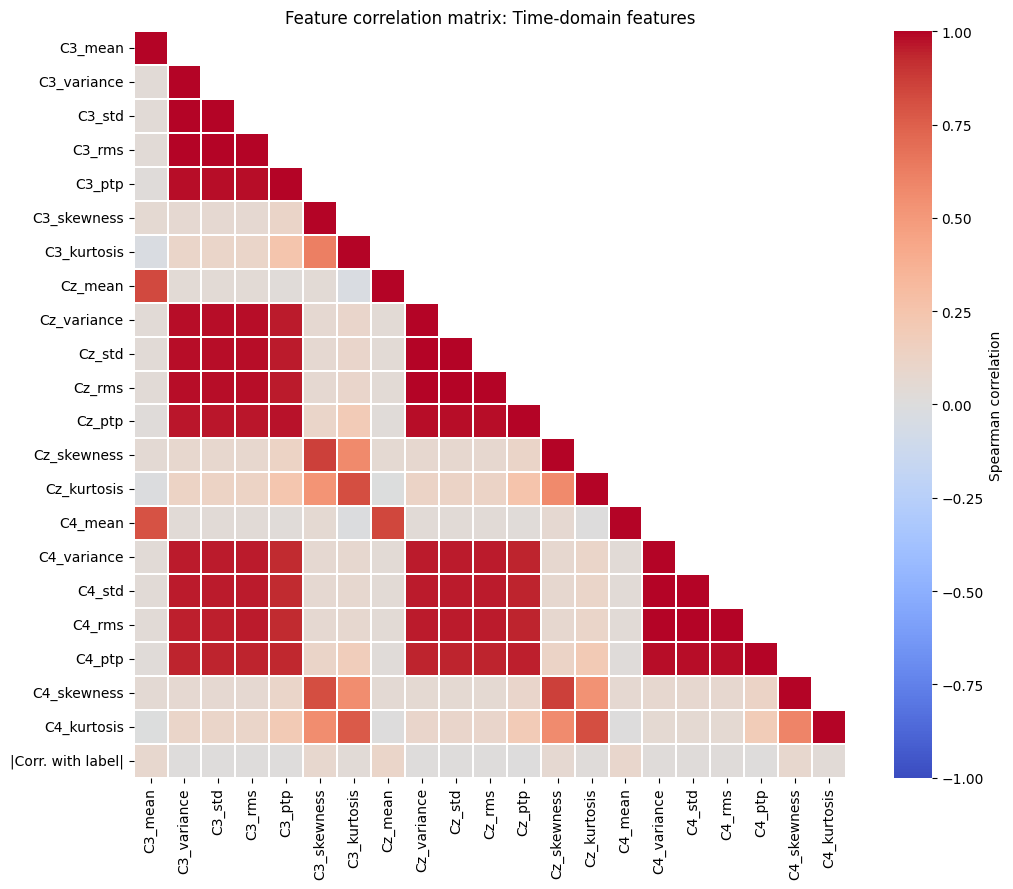

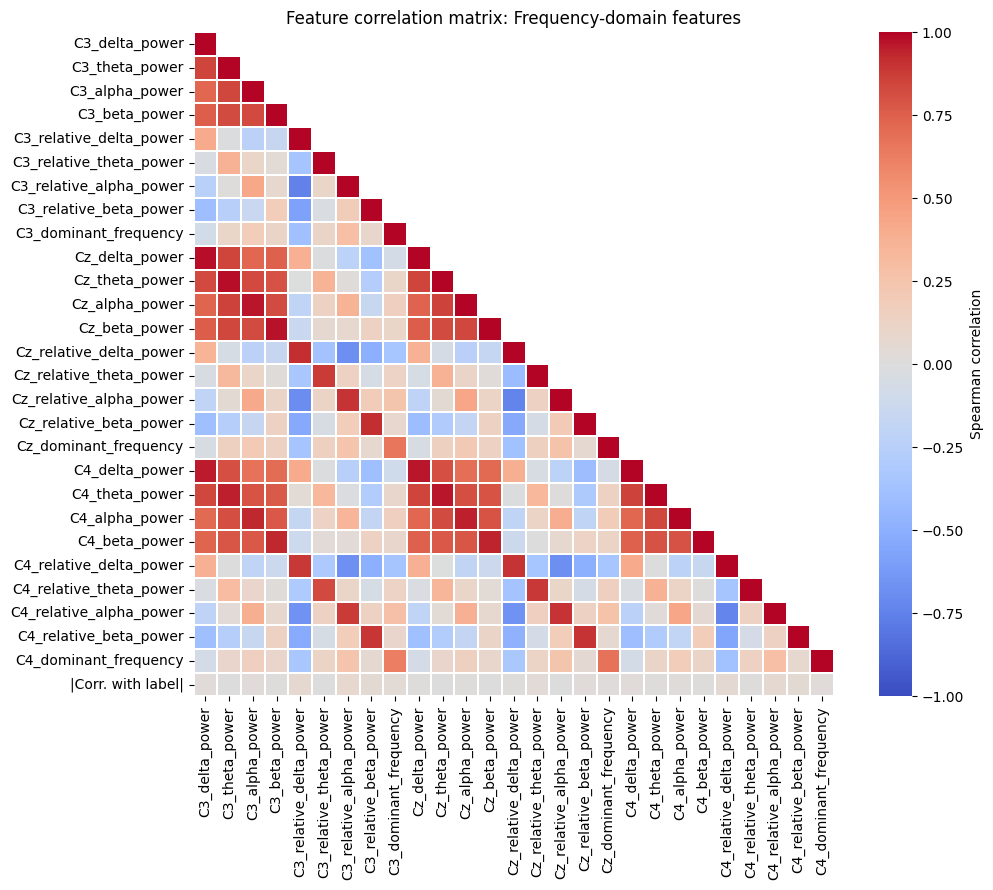

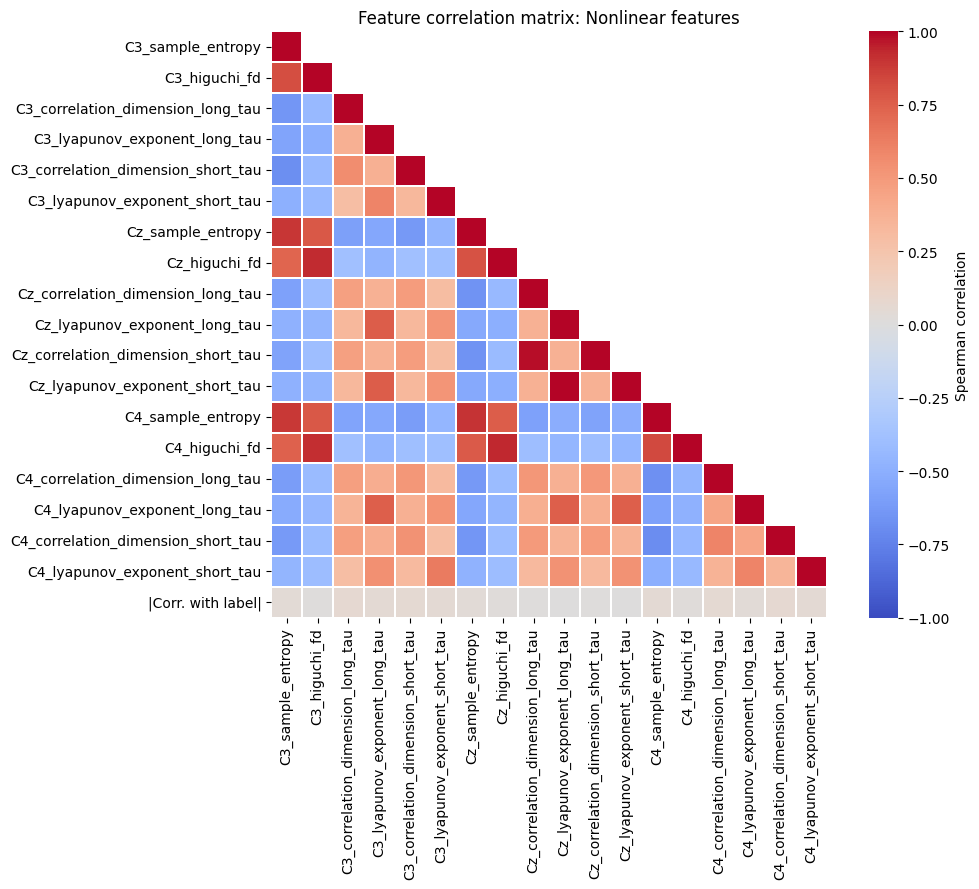

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_corr_matrix(data, y, title, figsize=(10, 8)):
    """
    Plot feature correlation matrix with an additional row showing
    the absolute Spearman correlation of each feature with the label.
    """

    # Feature-feature correlation
    corr = data.corr(method="spearman")

    # Feature-label correlation
    y_num = (y == "T2").astype(int)

    label_corr = data.apply(
        lambda x: x.corr(y_num, method="spearman")
    ).abs()

    # Append as last row
    corr_display = corr.copy()
    corr_display.loc["|Corr. with label|"] = label_corr

    # Mask only the feature-feature upper triangle
    mask = np.zeros(corr_display.shape, dtype=bool)
    mask[:-1, :] = np.triu(
        np.ones((corr.shape[0], corr.shape[1]), dtype=bool),
        k=1
    )

    plt.figure(figsize=figsize)

    sns.heatmap(
        corr_display,
        mask=mask,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"label": "Spearman correlation"}
    )

    plt.title(title)
    plt.tight_layout()
    plt.show()


# Feature-family correlation
feature_families = {
    "Time-domain features": [
        "mean", "variance", "std", "rms", "ptp", "skewness", "kurtosis"
    ],
    "Frequency-domain features": [
        "delta_power", "theta_power", "alpha_power", "beta_power",
        "relative_delta_power", "relative_theta_power",
        "relative_alpha_power", "relative_beta_power",
        "dominant_frequency"
    ],
    "Nonlinear features": [
        "sample_entropy", "higuchi_fd",
        "correlation_dimension_long_tau", "lyapunov_exponent_long_tau",
        "correlation_dimension_short_tau", "lyapunov_exponent_short_tau"
    ],
}

for family_name, suffixes in feature_families.items():

    family_cols = [
        col for col in X_train.columns
        if any(col.endswith(suffix) for suffix in suffixes)
    ]

    plot_corr_matrix(
        X_train[family_cols],
        y_train,
        title=f"Feature correlation matrix: {family_name}",
        figsize=(11, 9)
    )

**Observation**:
1. **Time-domain** heatmap - several groups of highly correlated features: **variance, standard deviation, RMS, and peak-to-peak amplitude** form a strongly correlated cluster within each channel, indicating that they capture similar aspects of signal amplitude. Likewise, **skewness and kurtosis** exhibit a moderate-to-strong correlation, reflecting related properties of the signal distribution. Similar feature groups are also correlated across channels (C3, Cz, and C4), suggesting that neighboring motor cortex electrodes exhibit comparable statistical characteristics. The additional row showing the correlation with the class label shows no strong correlation between any of the features and class label.

2. **Frequency-domain** heatmap - **absolute band powers** (delta, theta, alpha, and beta) form a strongly correlated group both within and across channels, indicating that they largely reflect the overall signal energy. In contrast, the relative band powers exhibit substantially weaker correlations with one another, as they describe the distribution of spectral energy rather than its absolute magnitude. The dominant frequency also shows only weak-to-moderate correlations with the power-based features, suggesting that it captures a different aspect of the EEG spectrum.

3. **Nonlinear heatmap** - **sample entropy and Higuchi fractal dimension** are strongly positively correlated across all channels, suggesting that both quantify related aspects of signal complexity. In contrast, these measures are **negatively correlated with the correlation dimension and largest Lyapunov exponent**, indicating that they capture different characteristics of the underlying dynamics.

#### FEATURE SELECTION METHODS
- ANOVA-F, Mutual Information

In [66]:
from sklearn.feature_selection import SelectKBest, f_classif

anova = SelectKBest(
    score_func=f_classif,
    k=15
)

anova.fit(X_train, y_train)

anova_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "ANOVA score": anova.scores_
}).sort_values("ANOVA score", ascending=False)

anova_scores.head(20)


,Feature,ANOVA score
22,Cz_mean,31.905431
49,C4_skewness,29.755882
5,C3_skewness,27.769357
44,C4_mean,24.970348
27,Cz_skewness,21.042324
11,C3_relative_delta_power,17.933334
0,C3_mean,17.843368
13,C3_relative_alpha_power,16.041776
55,C4_relative_delta_power,14.220478
19,C3_lyapunov_exponent_long_tau,11.465251


In [67]:
from sklearn.feature_selection import mutual_info_classif

mi = SelectKBest(
    score_func=mutual_info_classif,
    k=15
)

mi.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "MI score": mi.scores_
}).sort_values("MI score", ascending=False)

mi_scores.head(20)

,Feature,MI score
32,Cz_beta_power,0.020203
56,C4_relative_theta_power,0.017845
21,C3_lyapunov_exponent_short_tau,0.015806
27,Cz_skewness,0.015509
48,C4_ptp,0.015358
49,C4_skewness,0.013243
6,C3_kurtosis,0.013137
60,C4_sample_entropy,0.012674
16,C3_sample_entropy,0.011643
11,C3_relative_delta_power,0.010537


In [68]:
#COMPARISON (average rank)

anova_scores["ANOVA rank"] = anova_scores["ANOVA score"].rank(ascending=False)
mi_scores["MI rank"] = mi_scores["MI score"].rank(ascending=False)

ranking = (
    anova_scores[["Feature", "ANOVA rank"]]
    .merge(
        mi_scores[["Feature", "MI rank"]],
        on="Feature"
    )
)

ranking["Average rank"] = (
    ranking["ANOVA rank"] +
    ranking["MI rank"]
) / 2

ranking = ranking.sort_values("Average rank")

ranking

,Feature,ANOVA rank,MI rank,Average rank
1,C4_skewness,2.0,6.0,4.00
4,Cz_skewness,5.0,4.0,4.50
10,C3_lyapunov_exponent_short_tau,11.0,3.0,7.00
5,C3_relative_delta_power,6.0,10.0,8.00
12,C4_sample_entropy,13.0,8.0,10.50
...,...,...,...,...
47,Cz_delta_power,48.0,57.5,52.75
55,C4_variance,56.0,57.5,56.75
58,Cz_lyapunov_exponent_short_tau,59.5,57.5,58.50
59,Cz_lyapunov_exponent_long_tau,59.5,57.5,58.50


***Observation.** The feature ranking does not show too much consistency in ranking between two selection methods, and there is not indication of some feature being a strong predictor.*

## 3. Classification

Models used:

1. **Decision Tree** (directly interpretable)

2. **RIPPER** (ruleset, directly interpretable)

3. **XGBoost** (ensemble, not directly interpretable)

Evaluation using **subject-wise 5-fold CV**

### 3.1. Decision Tree
- using top 10 features

In [69]:
top10_features = (
    ranking
    .sort_values("Average rank")   # or "Consensus rank" if you renamed it
    .head(10)["Feature"]
    .tolist()
)

top10_features

['C4_skewness',
 'Cz_skewness',
 'C3_lyapunov_exponent_short_tau',
 'C3_relative_delta_power',
 'C4_sample_entropy',
 'C4_mean',
 'C3_sample_entropy',
 'C3_relative_alpha_power',
 'C3_kurtosis',
 'C3_dominant_frequency']

In [71]:
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.base import clone
import numpy as np

X_sel = features_df[top10_features]
y = features_df["label"]
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

y_pred_top10 = np.empty(len(y), dtype=object)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_sel, y, groups), start=1):
    model = clone(base_model)

    model.fit(X_sel.iloc[train_idx], y.iloc[train_idx])
    y_pred_top10[test_idx] = model.predict(X_sel.iloc[test_idx])


print(f"Accuracy : {accuracy_score(y, y_pred_top10):.3f}")
print(f"Precision: {precision_score(y, y_pred_top10, pos_label='T2'):.3f}")
print(f"Recall   : {recall_score(y, y_pred_top10, pos_label='T2'):.3f}")
print(f"F1-score : {f1_score(y, y_pred_top10, pos_label='T2'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred_top10))

Accuracy : 0.541
Precision: 0.535
Recall   : 0.606
F1-score : 0.568

Classification report
              precision    recall  f1-score   support

          T1       0.55      0.48      0.51      2452
          T2       0.54      0.61      0.57      2445

    accuracy                           0.54      4897
   macro avg       0.54      0.54      0.54      4897
weighted avg       0.54      0.54      0.54      4897



*The results are not much better than random guess. We will try a stronger (ensemble) model next.*

### 3.2. XGBoost

In [77]:
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np

top20_features = (
    ranking
    .sort_values("Average rank")
    .head(40)["Feature"]
    .tolist()
)

X_xgb = features_df[top20_features]
y = features_df["label"]
y_bin = (y == "T2").astype(int)
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)

y_pred_bin = np.empty(len(y_bin), dtype=int)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_xgb, y_bin, groups), start=1):
    model = clone(base_xgb)

    model.fit(
        X_xgb.iloc[train_idx],
        y_bin.iloc[train_idx]
    )

    y_pred_bin[test_idx] = model.predict(X_xgb.iloc[test_idx])

    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    print(f"Fold {fold}: subject overlap = {len(overlap)}")

y_pred = np.where(y_pred_bin == 1, "T2", "T1")

print(f"Accuracy : {accuracy_score(y, y_pred):.3f}")
print(f"Precision: {precision_score(y, y_pred, pos_label='T2'):.3f}")
print(f"Recall   : {recall_score(y, y_pred, pos_label='T2'):.3f}")
print(f"F1-score : {f1_score(y, y_pred, pos_label='T2'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred))

print("\nConfusion matrix")
print(confusion_matrix(y, y_pred, labels=["T1", "T2"]))

Fold 1: subject overlap = 0
Fold 2: subject overlap = 0
Fold 3: subject overlap = 0
Fold 4: subject overlap = 0
Fold 5: subject overlap = 0
Accuracy : 0.533
Precision: 0.533
Recall   : 0.524
F1-score : 0.529

Classification report
              precision    recall  f1-score   support

          T1       0.53      0.54      0.54      2452
          T2       0.53      0.52      0.53      2445

    accuracy                           0.53      4897
   macro avg       0.53      0.53      0.53      4897
weighted avg       0.53      0.53      0.53      4897


Confusion matrix
[[1329 1123]
 [1163 1282]]


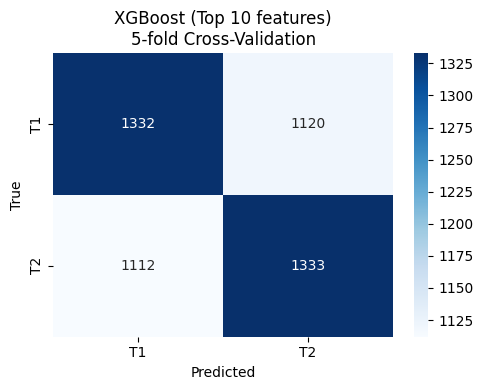

In [36]:
cm_xgb = confusion_matrix(y, y_pred, labels=["T1", "T2"])

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["T1", "T2"],
    yticklabels=["T1", "T2"],
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost (Top 10 features)\n5-fold Cross-Validation")

plt.tight_layout()
plt.show()

***Observation.** Even the stronger model was not successful in improving results, which suggests that the current feature set is too limited for this problem.*

## 4. Expanding features


In [92]:
import numpy as np
import pandas as pd

from tqdm import tqdm
from scipy.stats import skew, kurtosis
from scipy.signal import welch

import mne
from mne.io import read_raw_edf
from mne.datasets import eegbci

import antropy as ant
import nolds

N_SUBJECTS = 109
SUBJECTS = range(1, N_SUBJECTS + 1)
RUNS = [6, 10, 14]

CHANNELS = [
    "FC3", "FCz", "FC4",
    "C3", "Cz", "C4",
    "CP3", "CPz", "CP4",
]

# Motor imagery task:
# T1 = imagined both fists
# T2 = imagined both feet
EVENT_ID = {
    "T1": 2,
    "T2": 3,
}

LABEL_NAMES = {
    "T1": "Imagined fists",
    "T2": "Imagined feet",
}

TMIN = 0.0
TMAX = 4.0

FMIN = 1.0
FMAX = 40.0

epoch_rows = []

for subject in tqdm(SUBJECTS, desc="Epoching subjects"):

    files = eegbci.load_data(subject, runs=RUNS)

    for file, run in zip(files, RUNS):

        raw = read_raw_edf(file, preload=True, verbose=False)

        eegbci.standardize(raw)

        raw.pick(CHANNELS)

        raw.filter(
            l_freq=FMIN,
            h_freq=FMAX,
            fir_design="firwin",
            verbose=False
        )

        events, _ = mne.events_from_annotations(raw, verbose=False)

        epochs = mne.Epochs(
            raw,
            events,
            event_id=EVENT_ID,
            tmin=TMIN,
            tmax=TMAX,
            baseline=None,
            preload=True,
            verbose=False
        )

        sfreq = epochs.info["sfreq"]
        data = epochs.get_data(copy=True) * 1e6  # V -> µV

        inv_event_id = {v: k for k, v in EVENT_ID.items()}

        for epoch_idx, epoch_data in enumerate(data):

            label_code = epochs.events[epoch_idx, -1]
            label = inv_event_id[label_code]

            row = {
                "subject": subject,
                "run": run,
                "epoch": epoch_idx,
                "label": label,
                "label_name": LABEL_NAMES[label],
                "sfreq": sfreq,
            }

            for ch_idx, channel in enumerate(CHANNELS):
                row[channel] = epoch_data[ch_idx]

            epoch_rows.append(row)

epochs_df = pd.DataFrame(epoch_rows)

print(epochs_df.shape)
print(epochs_df["label"].value_counts())

epochs_df.head()

Epoching subjects:  91%|█████████ | 99/109 [00:13<00:01,  7.52it/s]C:\Users\Nikolina\AppData\Local\Temp\ipykernel_1428\1226022000.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = read_raw_edf(file, preload=True, verbose=False)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_1428\1226022000.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = read_raw_edf(file, preload=True, verbose=False)
C:\Users\Nikolina\AppData\Local\Temp\ipykernel_1428\1226022000.py:52: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = read_raw_edf(file, preload=True, verbose=False)
Epoching subjects: 100%|██████████| 109/109 [00:14<00:00,  7.44it/s]

(4897, 15)
label
T1    2452
T2    2445
Name: count, dtype: int64


,subject,run,epoch,label,label_name,sfreq,FC3,FCz,FC4,C3,Cz,C4,CP3,CPz,CP4
0,1,6,0,T2,Imagined feet,160.0,"[70.71232036319724, 68.10054648309594, 80.3408...","[88.10311826194038, 89.27030956999805, 99.2869...","[61.50885156107859, 62.981475766041946, 67.358...","[47.064663920283344, 51.896709824210674, 64.30...","[61.599042378512515, 60.9579394782651, 68.9704...","[46.20212460673687, 53.750296419015655, 60.365...","[32.713634697734705, 36.27764423272012, 50.393...","[42.591755527841826, 43.70413290581409, 51.946...","[36.6654550440904, 46.04066720936404, 53.02803..."
1,1,6,1,T1,Imagined fists,160.0,"[33.77555259668967, 28.373922341329187, 10.191...","[20.134924497491365, 27.602108522133783, 17.23...","[29.98941955698708, 25.488228557865558, 13.776...","[34.8853482605296, 26.828342214257756, 7.53468...","[38.7231736898472, 32.90767454071031, 11.45478...","[43.6375697126612, 34.166421250550584, 17.8051...","[24.377994135448176, 19.70868237693044, 2.1894...","[40.53972075938052, 30.53558092256506, 6.66910...","[41.92646391424091, 28.287064054917202, 9.5469..."
2,1,6,2,T1,Imagined fists,160.0,"[-19.298180792561975, -26.119912088928967, -34...","[-35.22662417383644, -50.18875351617976, -52.2...","[-14.946971550773519, -28.163779272327993, -34...","[-21.571030741303048, -32.208187289640755, -43...","[-35.163623742622505, -48.6533153732969, -50.7...","[5.6637498680118785, -12.753106114879428, -31....","[-32.94110132318214, -38.21079328768101, -39.8...","[-26.871008247618295, -36.06210420263842, -40....","[7.333333917016568, -11.492446924720781, -27.6..."
3,1,6,3,T2,Imagined feet,160.0,"[59.82035726370258, 60.97007607497823, 52.7611...","[67.17858572635456, 57.181982715226546, 43.358...","[52.435374206167516, 35.80000812856738, 22.125...","[60.67600003103479, 54.99254902629978, 40.7286...","[55.49427777438765, 40.40204857717364, 28.6282...","[44.692733335014445, 23.807781532792806, 14.79...","[46.91506344235863, 38.655307878704875, 28.637...","[44.524986645446326, 30.880350888736398, 23.92...","[35.502720507721776, 18.993773324377774, 17.88..."
4,1,6,4,T1,Imagined fists,160.0,"[107.14424368404455, 107.05580964723238, 113.5...","[130.54654217290113, 133.76327909495288, 137.6...","[105.25097089203803, 109.73722682453985, 109.7...","[105.52078890294472, 113.71931957723163, 122.0...","[126.98589352009795, 141.76272358736384, 154.2...","[89.84783019086548, 99.53227522632251, 104.020...","[86.30424189880357, 103.09409336771651, 114.47...","[97.16430681490381, 114.80526852799942, 127.12...","[79.98276593499726, 95.49876029573787, 106.077..."


In [93]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch

import antropy as ant

# Example broader MI-relevant channel set
CHANNELS = [
    "FC3", "FCz", "FC4",
    "C3", "Cz", "C4",
    "CP3", "CPz", "CP4",
]

def bandpower_welch(x, sfreq, band, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), int(2 * sfreq))

    freqs, psd = welch(x, fs=sfreq, nperseg=nperseg)
    mask = (freqs >= band[0]) & (freqs <= band[1])

    if not np.any(mask):
        return np.nan

    return np.trapezoid(psd[mask], freqs[mask])


def dominant_frequency(x, sfreq, fmin=1.0, fmax=30.0, nperseg=None):
    if nperseg is None:
        nperseg = min(len(x), int(2 * sfreq))

    freqs, psd = welch(x, fs=sfreq, nperseg=nperseg)
    mask = (freqs >= fmin) & (freqs <= fmax)

    if not np.any(mask):
        return np.nan

    freqs_sel = freqs[mask]
    psd_sel = psd[mask]

    return freqs_sel[np.argmax(psd_sel)]


def extract_channel_features(x, sfreq):
    features = {}

    # Time-domain features
    features["mean"] = np.mean(x)
    features["variance"] = np.var(x)
    features["std"] = np.std(x)
    features["rms"] = np.sqrt(np.mean(x ** 2))
    features["ptp"] = np.ptp(x)
    features["skewness"] = skew(x)
    features["kurtosis"] = kurtosis(x)

    # Frequency-domain features
    bands = {
        "delta": (1, 4),
        "theta": (4, 8),
        "alpha": (8, 13),
        "beta": (13, 30),
    }

    abs_powers = {}

    for band_name, band_range in bands.items():
        power = bandpower_welch(x, sfreq, band_range)
        abs_powers[band_name] = power
        features[f"{band_name}_power"] = power

    total_power = bandpower_welch(x, sfreq, (1, 30))

    for band_name, power in abs_powers.items():
        features[f"relative_{band_name}_power"] = (
            power / total_power if total_power > 0 else np.nan
        )

    features["dominant_frequency"] = dominant_frequency(x, sfreq)

    # Safe nonlinear features — no label, no embedding params
    try:
        features["sample_entropy"] = ant.sample_entropy(x)
    except Exception:
        features["sample_entropy"] = np.nan

    try:
        features["higuchi_fd"] = ant.higuchi_fd(x, kmax=8)
    except Exception:
        features["higuchi_fd"] = np.nan

    return features


feature_rows = []

for _, epoch in tqdm(epochs_df.iterrows(), total=len(epochs_df), desc="Extracting features"):

    row = {
        "subject": epoch["subject"],
        "run": epoch["run"],
        "epoch": epoch["epoch"],
        "label": epoch["label"],
        "label_name": epoch["label_name"],
    }

    sfreq = epoch["sfreq"]

    for channel in CHANNELS:

        if channel not in epoch.index:
            continue

        x = epoch[channel]

        feats = extract_channel_features(
            x=x,
            sfreq=sfreq
        )

        for feat_name, feat_value in feats.items():
            row[f"{channel}_{feat_name}"] = feat_value

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)

print(features_df.shape)
print(features_df["label"].value_counts())

features_df.to_csv("bci_mi_features_all_subjects_more_channels_no_lyap_corrdim.csv", index=False)

features_df.head()

Extracting features: 100%|██████████| 4897/4897 [01:20<00:00, 60.94it/s]


(4897, 167)
label
T1    2452
T2    2445
Name: count, dtype: int64


,subject,run,epoch,label,label_name,FC3_mean,FC3_variance,FC3_std,FC3_rms,FC3_ptp,...,CP4_theta_power,CP4_alpha_power,CP4_beta_power,CP4_relative_delta_power,CP4_relative_theta_power,CP4_relative_alpha_power,CP4_relative_beta_power,CP4_dominant_frequency,CP4_sample_entropy,CP4_higuchi_fd
0,1,6,0,T2,Imagined feet,-0.275162,1383.532030,37.195860,37.196878,226.766269,...,179.201023,132.458485,113.445150,0.449128,0.232218,0.171646,0.147008,1.5,0.979427,1.484383
1,1,6,1,T1,Imagined fists,1.372701,3796.377139,61.614748,61.630037,382.823694,...,169.257706,80.027650,151.029667,0.758152,0.102256,0.048348,0.091244,1.0,0.792723,1.511426
2,1,6,2,T1,Imagined fists,1.450649,2220.062509,47.117539,47.139865,327.925815,...,266.040251,167.287810,101.911353,0.610456,0.193623,0.121751,0.074170,1.0,0.812682,1.406755
3,1,6,3,T2,Imagined feet,0.277370,1533.816092,39.163964,39.164946,249.169284,...,131.067614,172.657182,147.423774,0.635047,0.106026,0.139669,0.119257,2.0,0.997729,1.467366
4,1,6,4,T1,Imagined fists,3.976236,7044.780840,83.933193,84.027325,743.742208,...,443.517113,340.280049,290.471739,0.691318,0.127441,0.097777,0.083465,1.0,0.590437,1.412587


In [94]:
from sklearn.model_selection import GroupShuffleSplit

metadata = ["subject", "run", "epoch", "label", "label_name"]

X = features_df.drop(columns=metadata)
y = features_df["label"]

groups = features_df["subject"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print("Train subjects:", features_df.iloc[train_idx]["subject"].nunique())
print("Test subjects :", features_df.iloc[test_idx]["subject"].nunique())

print(
    set(features_df.iloc[train_idx]["subject"])
    & set(features_df.iloc[test_idx]["subject"])
)

Train subjects: 87
Test subjects : 22
set()


In [95]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [96]:
from sklearn.feature_selection import SelectKBest, f_classif

anova = SelectKBest(
    score_func=f_classif,
    k=30
)

anova.fit(X_train, y_train)

anova_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "ANOVA score": anova.scores_
}).sort_values("ANOVA score", ascending=False)

anova_scores.head(20)


,Feature,ANOVA score
18,FCz_mean,33.179206
72,Cz_mean,31.905431
95,C4_skewness,29.755882
144,CP4_mean,27.976585
0,FC3_mean,27.812997
59,C3_skewness,27.769357
23,FCz_skewness,27.633834
126,CPz_mean,27.512368
90,C4_mean,24.970348
5,FC3_skewness,21.742595


In [97]:
from sklearn.feature_selection import mutual_info_classif

mi = SelectKBest(
    score_func=mutual_info_classif,
    k=30
)

mi.fit(X_train, y_train)

mi_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "MI score": mi.scores_
}).sort_values("MI score", ascending=False)

mi_scores.head(20)

,Feature,MI score
82,Cz_beta_power,0.020203
149,CP4_skewness,0.020200
43,FC4_delta_power,0.018628
2,FC3_std,0.018234
1,FC3_variance,0.018194
102,C4_relative_theta_power,0.017845
77,Cz_skewness,0.015509
94,C4_ptp,0.015358
5,FC3_skewness,0.014039
116,CP3_theta_power,0.013740


In [98]:
#COMPARISON (average rank)

anova_scores["ANOVA rank"] = anova_scores["ANOVA score"].rank(ascending=False)
mi_scores["MI rank"] = mi_scores["MI score"].rank(ascending=False)

ranking = (
    anova_scores[["Feature", "ANOVA rank"]]
    .merge(
        mi_scores[["Feature", "MI rank"]],
        on="Feature"
    )
)

ranking["Average rank"] = (
    ranking["ANOVA rank"] +
    ranking["MI rank"]
) / 2

ranking = ranking.sort_values("Average rank")

ranking

,Feature,ANOVA rank,MI rank,Average rank
2,C4_skewness,3.0,13.0,8.00
10,Cz_skewness,11.0,7.0,9.00
9,FC3_skewness,10.0,9.0,9.50
16,CP4_skewness,17.0,2.0,9.50
14,C3_relative_delta_power,15.0,26.0,20.50
...,...,...,...,...
153,CP3_delta_power,154.0,126.5,140.25
158,CP4_delta_power,159.0,126.5,142.75
159,FCz_dominant_frequency,160.0,126.5,143.25
160,CPz_delta_power,161.0,126.5,143.75


In [100]:
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import numpy as np

top20_features = (
    ranking
    .sort_values("Average rank")
    .head(30)["Feature"]
    .tolist()
)

X_xgb = features_df[top20_features]
y = features_df["label"]
y_bin = (y == "T2").astype(int)
groups = features_df["subject"]

cv = GroupKFold(n_splits=5)

base_xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
)

y_pred_bin = np.empty(len(y_bin), dtype=int)

for fold, (train_idx, test_idx) in enumerate(cv.split(X_xgb, y_bin, groups), start=1):
    model = clone(base_xgb)

    model.fit(
        X_xgb.iloc[train_idx],
        y_bin.iloc[train_idx]
    )

    y_pred_bin[test_idx] = model.predict(X_xgb.iloc[test_idx])

    overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
    print(f"Fold {fold}: subject overlap = {len(overlap)}")

y_pred = np.where(y_pred_bin == 1, "T2", "T1")

print(f"Accuracy : {accuracy_score(y, y_pred):.3f}")
print(f"Precision: {precision_score(y, y_pred, pos_label='T2'):.3f}")
print(f"Recall   : {recall_score(y, y_pred, pos_label='T2'):.3f}")
print(f"F1-score : {f1_score(y, y_pred, pos_label='T2'):.3f}")

print("\nClassification report")
print(classification_report(y, y_pred))

print("\nConfusion matrix")
print(confusion_matrix(y, y_pred, labels=["T1", "T2"]))

Fold 1: subject overlap = 0
Fold 2: subject overlap = 0
Fold 3: subject overlap = 0
Fold 4: subject overlap = 0
Fold 5: subject overlap = 0
Accuracy : 0.528
Precision: 0.528
Recall   : 0.526
F1-score : 0.527

Classification report
              precision    recall  f1-score   support

          T1       0.53      0.53      0.53      2452
          T2       0.53      0.53      0.53      2445

    accuracy                           0.53      4897
   macro avg       0.53      0.53      0.53      4897
weighted avg       0.53      0.53      0.53      4897


Confusion matrix
[[1303 1149]
 [1160 1285]]


*Expanded feature set didnt not improve results significantly. Adding more features with classical models is not recommended, instead DL models could perform automatic feature extraction via 1D conv.*